# 04 — Training the model from scratch

We have a correct, randomly-initialized GPT. Now we write the loop that turns it into one that
writes Shakespeare — and we build that loop **one concern at a time**, explaining why each piece
exists:

1. **Data loading** — turning the corpus into `(x, y)` next-token batches.
2. **The core loop** — forward → cross-entropy loss → backward → optimizer step.
3. **AdamW** with decoupled weight decay, and *which* parameters we decay.
4. **Cosine LR schedule with warmup** — why not a constant learning rate.
5. **Gradient clipping** — insurance against exploding gradients.
6. **Gradient accumulation** — big-batch training on a small GPU.
7. **Mixed precision** — 2× speed / half memory on CUDA.

Then we train the real thing and plot the loss curves. This is the consolidated, teaching version
of [`train.py`](../train.py); the script is what you'd launch for long unattended runs.

In [1]:
import sys, os, math, time, pickle
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from model import GPT, GPTConfig

ROOT = Path("..").resolve()
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)
torch.manual_seed(1337)

device: mps


## 1. Data: from a token stream to `(x, y)` batches

In notebook 01 we prepared `data/shakespeare_char/` as three files: `train.bin` and `val.bin`
(the corpus encoded as `uint16` token ids) and `meta.pkl` (the tokenizer info). We load the bins
with `np.memmap` — the array is backed by the file on disk and paged in on demand, so we never
have to fit the whole corpus in RAM. Overkill for 1MB of Shakespeare, essential for the ~500M
tokens of TinyStories in notebook 08. Same code path either way.

A training example is a chunk of `block_size` consecutive tokens `x`, paired with the *same chunk
shifted by one* as targets `y`. So the model sees positions `0..T-1` and must predict positions
`1..T` — that's next-token prediction, and every one of the T positions contributes a loss term.

In [2]:
if not (ROOT / "data" / "shakespeare_char" / "train.bin").exists():
    # (normally produced in notebook 01; regenerate here so this notebook is standalone)
    text = (ROOT / "data" / "tinyshakespeare.txt").read_text()
    chars = sorted(set(text)); stoi = {c:i for i,c in enumerate(chars)}
    ids = np.array([stoi[c] for c in text], dtype=np.uint16)
    n = int(0.9*len(ids)); os.makedirs(ROOT/"data"/"shakespeare_char", exist_ok=True)
    ids[:n].tofile(ROOT/"data"/"shakespeare_char"/"train.bin")
    ids[n:].tofile(ROOT/"data"/"shakespeare_char"/"val.bin")
    pickle.dump({"vocab_size":len(chars),"kind":"char","stoi":stoi,
                 "itos":{i:c for i,c in enumerate(chars)}},
                open(ROOT/"data"/"shakespeare_char"/"meta.pkl","wb"))

data_dir = ROOT / "data" / "shakespeare_char"
train_data = np.memmap(data_dir/"train.bin", dtype=np.uint16, mode="r")
val_data   = np.memmap(data_dir/"val.bin",   dtype=np.uint16, mode="r")
meta = pickle.load(open(data_dir/"meta.pkl","rb"))
print(f"vocab={meta['vocab_size']}  train={len(train_data):,} tokens  val={len(val_data):,} tokens")

block_size = 256
batch_size = 64

def get_batch(split):
    d = train_data if split == "train" else val_data
    # pick batch_size random start positions; each yields a block_size window
    ix = torch.randint(len(d) - block_size - 1, (batch_size,))
    x = torch.stack([torch.from_numpy(d[i:i+block_size].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(d[i+1:i+1+block_size].astype(np.int64)) for i in ix])
    # non_blocking + pin isn't needed on MPS; keep it simple
    return x.to(device), y.to(device)

xb, yb = get_batch("train")
print("x:", tuple(xb.shape), " y:", tuple(yb.shape))
print("y is x shifted by one:", torch.equal(xb[0,1:], yb[0,:-1]))

vocab=65  train=1,003,854 tokens  val=111,540 tokens
x: (64, 256)  y: (64, 256)
y is x shifted by one: True


Note we sample **random windows** rather than marching through the text in order. With ~1M
tokens and only a few thousand steps we'll never see all overlaps anyway, and random sampling
decorrelates consecutive batches (nearby windows share most of their tokens), which stabilizes
the gradient estimate. This is the nanoGPT convention.

## 2. The core training loop

Stripped to its essence, training is four lines repeated:

```python
logits, loss = model(x, y)   # forward: predictions + cross-entropy vs next token
optimizer.zero_grad()        # clear gradients from the previous step
loss.backward()              # backprop: fill every .grad
optimizer.step()             # nudge each weight down its gradient
```

Everything else in this notebook is *making this converge faster and more stably*. Let's add
those refinements before the real run.

## 3. AdamW, and which parameters get weight decay

**Why Adam over plain SGD?** Adam keeps a per-parameter running estimate of the gradient's mean
and variance, effectively giving each weight its own adaptive learning rate. Transformers have
wildly different gradient scales across embeddings, attention, and LayerNorm; Adam handles that
out of the box, where SGD would need heavy tuning. We use **betas (0.9, 0.95)** — the slightly
lower β₂ than the 0.999 default is the GPT convention, making the variance estimate a bit more
responsive.

**Why *AdamW* specifically?** Weight decay = a pull toward zero, a prior that small weights
generalize better. Classic Adam entangles it with the adaptive scaling (it gets divided by the
gradient variance too), which weakens it unpredictably. AdamW *decouples* it: decay is applied
directly to the weights, exactly as intended.

**Which parameters to decay?** Only the ≥2-D tensors — the matmul weights and embeddings.
Decaying a **LayerNorm gain/bias** or a **bias** vector is wrong: those are per-feature scale/shift
knobs, not directions in a linear map, and shrinking them toward zero just fights the model. So we
split parameters into two groups.

In [3]:
def configure_optimizer(model, weight_decay=0.1, lr=1e-3):
    decay, no_decay = [], []
    for p in model.parameters():
        if p.requires_grad:
            (decay if p.dim() >= 2 else no_decay).append(p)   # >=2D: weights; <2D: norms/biases
    groups = [{"params": decay,    "weight_decay": weight_decay},
              {"params": no_decay, "weight_decay": 0.0}]
    print(f"decayed tensors: {len(decay)} ({sum(p.numel() for p in decay):,} params)")
    print(f"no-decay tensors: {len(no_decay)} ({sum(p.numel() for p in no_decay):,} params)")
    return torch.optim.AdamW(groups, lr=lr, betas=(0.9, 0.95))

## 4. Learning-rate schedule: linear warmup → cosine decay

A constant LR is a poor choice at both ends of training:

- **Early:** Adam's mean/variance estimates start at zero and are unreliable for the first
  hundred-ish steps. A full-size LR here can throw the weights somewhere bad before the estimates
  settle. **Warmup** ramps the LR linearly from 0, letting the moments warm up first.
- **Late:** near a minimum, a big LR bounces around it instead of settling in. **Cosine decay**
  smoothly anneals the LR down to a small floor, letting the model fine-tune into the basin.

This warmup-then-cosine shape is the standard recipe for training transformers. Let's define it
and plot it.

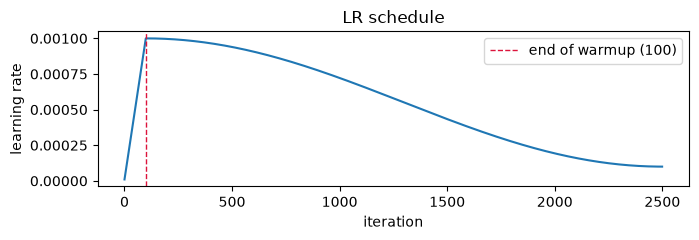

In [4]:
max_iters   = 2500
warmup_iters = 100
lr_max, lr_min = 1e-3, 1e-4

def get_lr(it):
    if it < warmup_iters:                       # linear warmup
        return lr_max * (it + 1) / warmup_iters
    if it >= max_iters:
        return lr_min
    ratio = (it - warmup_iters) / (max_iters - warmup_iters)
    coeff = 0.5 * (1 + math.cos(math.pi * ratio))   # 1 -> 0 over the run
    return lr_min + coeff * (lr_max - lr_min)

plt.figure(figsize=(7,2.5))
plt.plot([get_lr(i) for i in range(max_iters)])
plt.axvline(warmup_iters, color="crimson", ls="--", lw=1, label=f"end of warmup ({warmup_iters})")
plt.xlabel("iteration"); plt.ylabel("learning rate"); plt.legend(); plt.title("LR schedule")
plt.tight_layout(); plt.show()

## 5. Gradient clipping

Occasionally a batch produces an enormous gradient (a rare token, an unlucky init corner). A
single oversized step can undo thousands of good ones. **Gradient clipping** rescales the whole
gradient so its global L2 norm never exceeds a threshold (we use 1.0): direction preserved,
magnitude capped. Cheap insurance against a training-run-ending spike.

```python
torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # between backward() and step()
```

## 6. Gradient accumulation

The gradient you get from a big batch is a lower-variance estimate → smoother, faster training.
But a big batch may not fit in memory. **Gradient accumulation** fakes it: run several small
"micro-batches", call `backward()` on each (gradients *sum* into `.grad` because we don't zero
between them), and only `step()` after N of them. Divide each micro-loss by N so the accumulated
gradient equals the true large-batch average. We set `grad_accum_steps=1` here (Shakespeare batches
fit easily) but the loop is written to support it — you'll turn it up for TinyStories.

## 7. Mixed precision

On CUDA, doing matmuls in 16-bit (`bfloat16`/`float16`) instead of `float32` is ~2× faster and
uses half the memory, for negligible quality loss — `torch.autocast` picks per-op precision
automatically. `float16` has a tiny dynamic range and underflows small gradients to zero, so it
needs a **GradScaler** (multiply the loss up before backward, unscale before the step);
`bfloat16` has float32's range and skips that. Apple's MPS backend runs float32 here, so this is a
no-op on our Mac but active on a Colab T4 — the code below branches on the device so the *same
notebook* uses AMP when a GPU is present.

In [5]:
from contextlib import nullcontext
use_amp   = device.type == "cuda"
amp_dtype = torch.bfloat16 if (use_amp and torch.cuda.is_bf16_supported()) else torch.float16
autocast  = torch.autocast(device_type="cuda", dtype=amp_dtype) if use_amp else nullcontext()
scaler    = torch.amp.GradScaler("cuda", enabled=use_amp and amp_dtype == torch.float16)
print(f"mixed precision: {'off (fp32)' if not use_amp else amp_dtype}")

mixed precision: off (fp32)


## Putting it together and training

Model: **4 layers, 4 heads, 128-dim, 256 context** ≈ 0.8M parameters. Every `eval_interval`
steps we estimate train and val loss over several batches (a single-batch loss is too noisy to
track). We keep the best-val checkpoint — that's the one we'll sample from and reuse in later
notebooks.

In [6]:
config = GPTConfig(vocab_size=meta["vocab_size"], block_size=block_size,
                   n_layer=4, n_head=4, n_embd=128, dropout=0.1)
model = GPT(config).to(device)
print(f"model: {model.num_params()/1e6:.2f}M parameters")

optimizer = configure_optimizer(model, weight_decay=0.1, lr=lr_max)
grad_accum_steps, grad_clip = 1, 1.0
eval_interval, eval_iters = 250, 100

@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    for split in ("train", "val"):
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            x, y = get_batch(split)
            with autocast:
                _, loss = model(x, y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

model: 0.80M parameters
decayed tensors: 18 (827,520 params)
no-decay tensors: 9 (1,152 params)


In [7]:
history, best_val = [], float("inf")
t0 = time.time()
for it in range(max_iters + 1):
    for g in optimizer.param_groups:            # apply the scheduled LR
        g["lr"] = get_lr(it)

    if it % eval_interval == 0 or it == max_iters:
        losses = estimate_loss()
        history.append((it, losses["train"], losses["val"]))
        print(f"iter {it:5d} | train {losses['train']:.4f} | val {losses['val']:.4f} "
              f"| lr {get_lr(it):.2e} | {time.time()-t0:5.0f}s")
        if losses["val"] < best_val:
            best_val = losses["val"]
            os.makedirs(ROOT/"checkpoints", exist_ok=True)
            torch.save({"model": model.state_dict(), "config": config,
                        "meta": meta, "iter": it, "val_loss": best_val, "history": history},
                       ROOT/"checkpoints"/"shakespeare_char.pt")
    if it == max_iters:
        break

    optimizer.zero_grad(set_to_none=True)
    for _ in range(grad_accum_steps):
        x, y = get_batch("train")
        with autocast:
            _, loss = model(x, y)
            loss = loss / grad_accum_steps      # so accumulated grad = mean, not sum
        scaler.scale(loss).backward()
    scaler.unscale_(optimizer)                  # clip real (unscaled) gradients
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    scaler.step(optimizer)
    scaler.update()

print(f"\ndone in {(time.time()-t0)/60:.1f} min. best val loss: {best_val:.4f}")

iter     0 | train 4.2149 | val 4.2114 | lr 1.00e-05 |    12s


iter   250 | train 2.3546 | val 2.3791 | lr 9.91e-04 |    74s


iter   500 | train 2.0586 | val 2.1286 | lr 9.40e-04 |   137s


iter   750 | train 1.7941 | val 1.9278 | lr 8.47e-04 |   199s


iter  1000 | train 1.6466 | val 1.7982 | lr 7.22e-04 |   264s


...

iter  1500 | train 1.5068 | val 1.6893 | lr 4.34e-04 |   390s


iter  1750 | train 1.4681 | val 1.6594 | lr 3.00e-04 |   454s


iter  2000 | train 1.4425 | val 1.6345 | lr 1.93e-04 |   523s


iter  2250 | train 1.4271 | val 1.6176 | lr 1.24e-04 |   592s


iter  2500 | train 1.4168 | val 1.6089 | lr 1.00e-04 |   659s

done in 11.0 min. best val loss: 1.6089


## The loss curves

The single most informative plot in all of training. What to read from it:

- **Both curves fall** and flatten → the model is learning and we're near this size's capacity.
- **Train ≈ val** → we're **not overfitting**; with 1M tokens and <1M params and only ~1 epoch of
  effective data, memorization isn't a risk here. If val had turned *up* while train kept falling,
  that gap would be overfitting and we'd add regularization or stop early.
- A char-level val loss around **~1.5** corresponds to the model being genuinely uncertain over
  only a handful of plausible next characters — good enough for recognizable Shakespearean text.

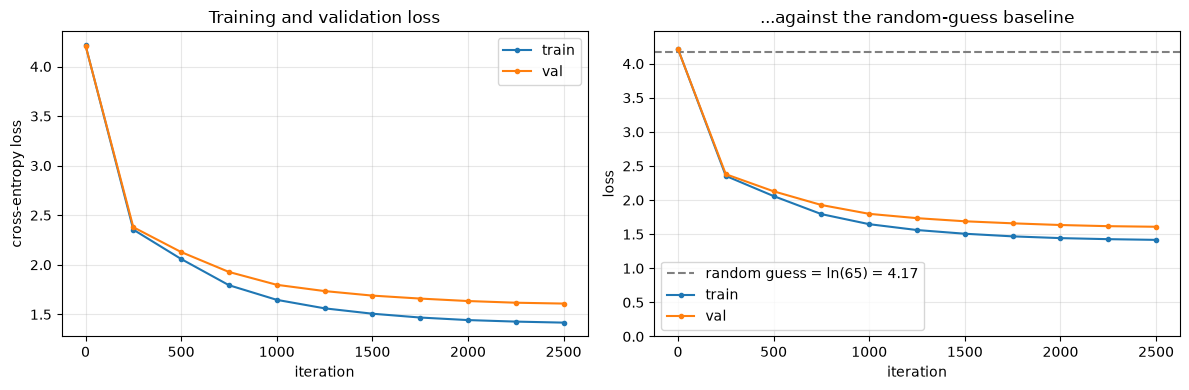

saved assets/shakespeare_loss.png


In [8]:
its   = [h[0] for h in history]
tr    = [h[1] for h in history]
va    = [h[2] for h in history]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(its, tr, "-o", ms=3, label="train")
ax[0].plot(its, va, "-o", ms=3, label="val")
ax[0].set_xlabel("iteration"); ax[0].set_ylabel("cross-entropy loss")
ax[0].set_title("Training and validation loss"); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].axhline(math.log(meta["vocab_size"]), color="gray", ls="--",
              label=f"random guess = ln({meta['vocab_size']}) = {math.log(meta['vocab_size']):.2f}")
ax[1].plot(its, tr, "-o", ms=3, label="train")
ax[1].plot(its, va, "-o", ms=3, label="val")
ax[1].set_xlabel("iteration"); ax[1].set_ylabel("loss"); ax[1].set_ylim(0, math.log(meta['vocab_size'])+0.3)
ax[1].set_title("...against the random-guess baseline"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()
os.makedirs(ROOT/"assets", exist_ok=True)
plt.savefig(ROOT/"assets"/"shakespeare_loss.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved assets/shakespeare_loss.png")

## A first taste of the output

We built `GPT.generate` in `model.py`; notebook 05 dissects the sampling strategies. Here's a
quick greedy-ish sample from our freshly trained model, just to confirm it learned *something*
that looks like English (well, Shakespeare):

In [9]:
decode = lambda ids: "".join(meta["itos"][i] for i in ids)
model.eval()
start = torch.tensor([[meta["stoi"]["\n"]]], device=device)
sample = model.generate(start, max_new_tokens=400, temperature=0.8, top_k=40, use_cache=True)
print(decode(sample[0].tolist()))


Thy solder charge are cousin,
Be father charge the done to them of your work:
The makess applace more fliends of you
To have this of love and hand me with gentleman.

KING RICHARD II:
I will think but me, that's didreas?

Third Murderer:
And, sir, by banish'd complose, do you, goo mat cen my,
My are ore
Ale be wisige y whe hon a the t t bomas clourcle t I in themo themat ath he t isthe y s the alo


It won't be Hamlet, but at ~0.8M parameters and a few minutes of training it produces
character names in ALL CAPS, colon-terminated speaker lines, roughly Elizabethan diction, and
mostly-real words — the structure of a Shakespeare play, learned purely from next-character
prediction. That's the payoff.

## Takeaways

- The training loop is fundamentally four lines (forward, zero_grad, backward, step); everything
  else exists to make it **converge faster and more stably**.
- **AdamW** with betas (0.9, 0.95) and weight decay **only on ≥2-D weights** (never LayerNorm
  gains or biases) is the transformer default.
- **Warmup** protects the early steps while Adam's moment estimates settle; **cosine decay** lets
  the model settle into a minimum. Together they beat a constant LR reliably.
- **Gradient clipping** (norm 1.0) prevents a single bad batch from wrecking the run;
  **gradient accumulation** simulates large batches on small hardware; **mixed precision** doubles
  throughput on a real GPU.
- **Read the loss curves:** falling-and-flattening = learning; train≈val = not overfitting;
  compare to `ln(vocab_size)` to know the model beats random.

**Interview quick-fire:**
- *Why warmup?* → Adam's variance estimate is unreliable early; a big LR then can destabilize training. Ramp it up.
- *Why AdamW over Adam?* → decoupled weight decay: the decay isn't distorted by Adam's adaptive scaling.
- *Which params do you exclude from weight decay?* → 1-D params — LayerNorm scales/biases and biases; decaying them fights the model.
- *What's gradient accumulation for?* → to get a large-batch gradient when a large batch won't fit in memory.

**Next:** [05 — Sampling](05_sampling.ipynb): greedy, temperature, top-k, and top-p, implemented
from scratch, with side-by-side samples so you can *see* what each knob does.